# RAG 检索层评估 Pipeline

完整的 RAG 检索层离线评估流水线。加载 golden dataset，运行检索（支持真实/模拟两种模式），计算核心指标和上下文质量，可视化结果，并对比不同分块策略的检索效果。

**适用场景：**
- 对比不同 chunking / embedding / retriever 策略
- 诊断 Recall vs. Precision 的权衡
- 识别噪声或重复过高的检索模式
- 导出 JSON 报告接入 CI 或 dashboard
- 加载多份实验报告进行策略横评

## 1. 环境与依赖

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path
from statistics import mean, stdev
from typing import Any

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from evaluation.retrieval_metrics.metrics import (
    context_redundancy_at_k,
    mrr,
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
)
from evaluation.retrieval_metrics.matching import (
    RetrievedItem,
    RelevantSource,
    build_retrieved_item,
    match_retrieved_to_relevant_sources,
    relevant_source_from_dict,
)
from evaluation.retrieval_metrics.evaluator import evaluate_retrieval_case

sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
})
%matplotlib inline

## 2. 运行配置

In [2]:
DATASET_PATH = "datasets/golden_retrieval.example.jsonl"
OUTPUT_DIR = Path("results")
TOP_K = 5
EXPERIMENT_NAME = "notebook-run"
USE_QUERY_PROCESSOR = False
LIVE_MODE = False

dataset_file = Path(DATASET_PATH)
if not dataset_file.exists():
    raise FileNotFoundError(f"找不到 golden dataset: {dataset_file.resolve()}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"数据集: {dataset_file.resolve()}")
print(f"Top-K: {TOP_K}")
print(f"模式: {'真实检索 (需要 Qdrant + Embedding 服务)' if LIVE_MODE else '模拟检索 (可离线运行)'}")

数据集: /Users/chris/Desktop/local-rag-system/evaluation/datasets/golden_retrieval.example.jsonl
Top-K: 5
模式: 模拟检索 (可离线运行)


## 3. 加载 Golden Dataset

In [3]:
def load_dataset(path: str) -> list[dict[str, Any]]:
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if "question" not in rec:
                raise ValueError(f"记录缺少 question 字段: {rec.get('id', '?')}")
            records.append(rec)
    return records

dataset = load_dataset(DATASET_PATH)
print(f"已加载 {len(dataset)} 条 golden questions\n")

for rec in dataset[:5]:
    n_sources = len(rec.get("relevant_sources", []))
    print(f"  [{rec['id']}] {rec['question'][:70]}...  ({n_sources} 个相关来源)")
if len(dataset) > 5:
    print(f"  ... 还有 {len(dataset) - 5} 条")

已加载 22 条 golden questions

  [q01] What is the organizational structure of the AI Engineering department?...  (3 个相关来源)
  [q02] What is the mission and vision of the Global Search team?...  (1 个相关来源)
  [q03] What is the difference between Code Completion and Code Generation?...  (2 个相关来源)
  [q04] How does Duo Chat handle resiliency when external LLM providers fail?...  (1 个相关来源)
  [q05] What are the three components of career development at GitLab?...  (4 个相关来源)
  ... 还有 17 条


## 4. 运行检索评估

In [4]:
def run_live_retrieval(question: str, top_k: int) -> list[RetrievedItem]:
    """通过真实 Qdrant vectorstore 和 embedding 服务进行检索。"""
    from app.rag.retriever import retrieve_relevant_documents
    from app.rag.query_processor import process_query

    retrieval_query = process_query(question)["rewritten_query"] if USE_QUERY_PROCESSOR else question
    results = retrieve_relevant_documents(retrieval_query, top_k=top_k)
    return [
        build_retrieved_item(content=doc.page_content, metadata=doc.metadata, score=float(score) if score else None)
        for doc, score in results
    ]


def run_demo_retrieval(record: dict[str, Any], top_k: int) -> list[RetrievedItem]:
    """模拟检索结果，生成不同质量等级的检索效果，用于离线测试。

    生成合成 RetrievedItem，其中部分匹配 golden relevant_sources，
    其余为干扰项，从而产生有区分度的指标分布。
    """
    rng = np.random.RandomState(hash(record["id"]) % (2**31))
    sources = record.get("relevant_sources", [])

    items: list[RetrievedItem] = []

    for i, src in enumerate(sources):
        file_path = src.get("file_path", "unknown.md")
        text_hint = src.get("text", "relevant content")
        relevance = src.get("relevance", 1.0)

        if rng.random() < 0.55 + relevance * 0.12:
            rank_pos = rng.randint(0, min(top_k, len(sources) + 2))
            content = f"[模拟 chunk - {file_path}] 本文档详细讨论了 {text_hint}，提供了全面的主题覆盖及示例和最佳实践。"
            items.append(build_retrieved_item(
                content=content,
                metadata={"file_path": file_path, "chunk_index": i},
                score=1.0 - rank_pos * 0.12,
            ))

    distractor_topics = [
        "办公室零食政策", "2024 节假日日历", "食堂菜单",
        "v3.2.1 发布说明", "停车证续期",
        "团队 offsite 计划", "打印机故障排除指南",
        "差旅报销表", "电梯维护时间表",
    ]
    while len(items) < top_k:
        topic = distractor_topics[len(items) % len(distractor_topics)]
        items.append(build_retrieved_item(
            content=f"[模拟干扰项] 本页面涵盖 {topic} 及相关行政流程。",
            metadata={"file_path": f"noise/{topic}.md", "chunk_index": 99},
            score=0.3 - len(items) * 0.03,
        ))

    items.sort(key=lambda x: x.score if x.score is not None else 0.0, reverse=True)
    return items[:top_k]


print(f"正在以 {'真实' if LIVE_MODE else '模拟'} 模式运行评估...\n")

per_question_results = []
for rec in dataset:
    question = rec["question"]
    relevant_sources = [relevant_source_from_dict(s) for s in rec.get("relevant_sources", [])]

    if LIVE_MODE:
        retrieved_items = run_live_retrieval(question, TOP_K)
    else:
        retrieved_items = run_demo_retrieval(rec, TOP_K)

    eval_result = evaluate_retrieval_case(retrieved_items, relevant_sources, TOP_K)

    per_question_results.append({
        "id": rec["id"],
        "question": question,
        "num_relevant": len(relevant_sources),
        "num_retrieved": len(retrieved_items),
        "evaluation": eval_result.to_dict(),
    })
    print(f"  [{rec['id']}] recall@{TOP_K}={eval_result.core_metrics[f'recall@{TOP_K}']:.2f}  "
          f"precision@{TOP_K}={eval_result.core_metrics[f'precision@{TOP_K}']:.2f}  "
          f"mrr={eval_result.core_metrics['mrr']:.2f}")

print(f"\n共评估 {len(per_question_results)} 个问题。")

正在以 模拟 模式运行评估...

  [q01] recall@5=1.00  precision@5=0.60  mrr=1.00
  [q02] recall@5=1.00  precision@5=0.20  mrr=1.00
  [q03] recall@5=1.00  precision@5=0.20  mrr=1.00
  [q04] recall@5=1.00  precision@5=0.20  mrr=1.00
  [q05] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q06] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q07] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q08] recall@5=1.00  precision@5=0.20  mrr=1.00
  [q09] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q10] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q11] recall@5=1.00  precision@5=0.60  mrr=1.00
  [q12] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q13] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q14] recall@5=1.00  precision@5=0.20  mrr=1.00
  [q15] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q16] recall@5=1.00  precision@5=0.60  mrr=1.00
  [q17] recall@5=1.00  precision@5=0.20  mrr=1.00
  [q18] recall@5=1.00  precision@5=0.60  mrr=1.00
  [q19] recall@5=1.00  precision@5=0.40  mrr=1.00
  [q20] recall@5=1.00  precision

## 5. 构建结果 DataFrame

In [5]:
rows = []
for r in per_question_results:
    ev = r["evaluation"]
    rows.append({
        "id": r["id"],
        "问题": r["question"][:60],
        "相关来源数": r["num_relevant"],
        f"recall@{TOP_K}": ev["core_metrics"][f"recall@{TOP_K}"],
        f"precision@{TOP_K}": ev["core_metrics"][f"precision@{TOP_K}"],
        "mrr": ev["core_metrics"]["mrr"],
        f"ndcg@{TOP_K}": ev["core_metrics"][f"ndcg@{TOP_K}"],
        f"上下文冗余@{TOP_K}": ev["context_quality"][f"context_redundancy@{TOP_K}"],
        f"无关率@{TOP_K}": ev["context_quality"][f"irrelevant_rate@{TOP_K}"],
        f"重复率@{TOP_K}": ev["context_quality"][f"duplicate_rate@{TOP_K}"],
    })

df = pd.DataFrame(rows)
df.set_index("id", inplace=True)
df

,问题,相关来源数,recall@5,precision@5,mrr,ndcg@5,上下文冗余@5,无关率@5,重复率@5
id,,,,,,,,,
q01,What is the organizational structure of the AI...,3,1.0,0.6,1.0,1.000000,0.4,0.4,0.0
q02,What is the mission and vision of the Global S...,1,1.0,0.2,1.0,1.000000,0.8,0.8,0.0
q03,What is the difference between Code Completion...,2,1.0,0.2,1.0,0.613147,0.8,0.8,0.0
q04,How does Duo Chat handle resiliency when exter...,1,1.0,0.2,1.0,1.000000,0.8,0.8,0.0
q05,What are the three components of career develo...,4,1.0,0.4,1.0,0.190493,0.6,0.6,0.0
q06,What is the mentoring process and how should m...,3,1.0,0.4,1.0,0.713621,0.6,0.6,0.0
q07,How do you evaluate a new AI model for Code Su...,2,1.0,0.4,1.0,0.833991,0.6,0.6,0.0
q08,What feature flag process should be followed w...,2,1.0,0.2,1.0,0.613147,0.8,0.8,0.0
q09,Who owns the different parts of editor extensi...,3,1.0,0.4,1.0,0.855669,0.6,0.6,0.0


## 6. 聚合指标统计

In [6]:
def aggregate_metrics(results: list[dict[str, Any]]) -> dict[str, dict[str, float]]:
    """对所有问题的 core_metrics 和 context_quality 计算均值与标准差。"""
    agg: dict[str, dict[str, float]] = {}
    for group in ("core_metrics", "context_quality"):
        metric_names = results[0]["evaluation"][group].keys()
        agg[group] = {}
        for name in metric_names:
            vals = [r["evaluation"][group][name] for r in results]
            agg[group][f"{name}_mean"] = mean(vals)
            agg[group][f"{name}_std"] = stdev(vals) if len(vals) > 1 else 0.0
    return agg

agg = aggregate_metrics(per_question_results)

print("=" * 56)
print(f"{'检索评估汇总':^50}")
print(f"{'数据集: ' + DATASET_PATH:^56}")
print(f"{'评估问题数: ' + str(len(per_question_results)):^56}")
print(f"{'Top-K: ' + str(TOP_K):^56}")
print("=" * 56)
print()
print("--- 核心检索指标 ---")
for k, v in agg["core_metrics"].items():
    print(f"  {k:<28s} {v:>8.4f}")
print()
print("--- 上下文质量指标 ---")
for k, v in agg["context_quality"].items():
    print(f"  {k:<28s} {v:>8.4f}")

                      检索评估汇总                      
      数据集: datasets/golden_retrieval.example.jsonl      
                       评估问题数: 22                        
                        Top-K: 5                        

--- 核心检索指标 ---
  recall@5_mean                  1.0000
  recall@5_std                   0.0000
  precision@5_mean               0.3545
  precision@5_std                0.1503
  mrr_mean                       1.0000
  mrr_std                        0.0000
  ndcg@5_mean                    0.8089
  ndcg@5_std                     0.1955

--- 上下文质量指标 ---
  context_redundancy@5_mean      0.6455
  context_redundancy@5_std       0.1503
  irrelevant_rate@5_mean         0.6455
  irrelevant_rate@5_std          0.1503
  duplicate_rate@5_mean          0.0000
  duplicate_rate@5_std           0.0000


## 7. 逐题核心指标

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2362116298.py:19: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2362116298.py:19: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2362116298.py:19: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2362116298.py:19: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2362116298.py:19: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

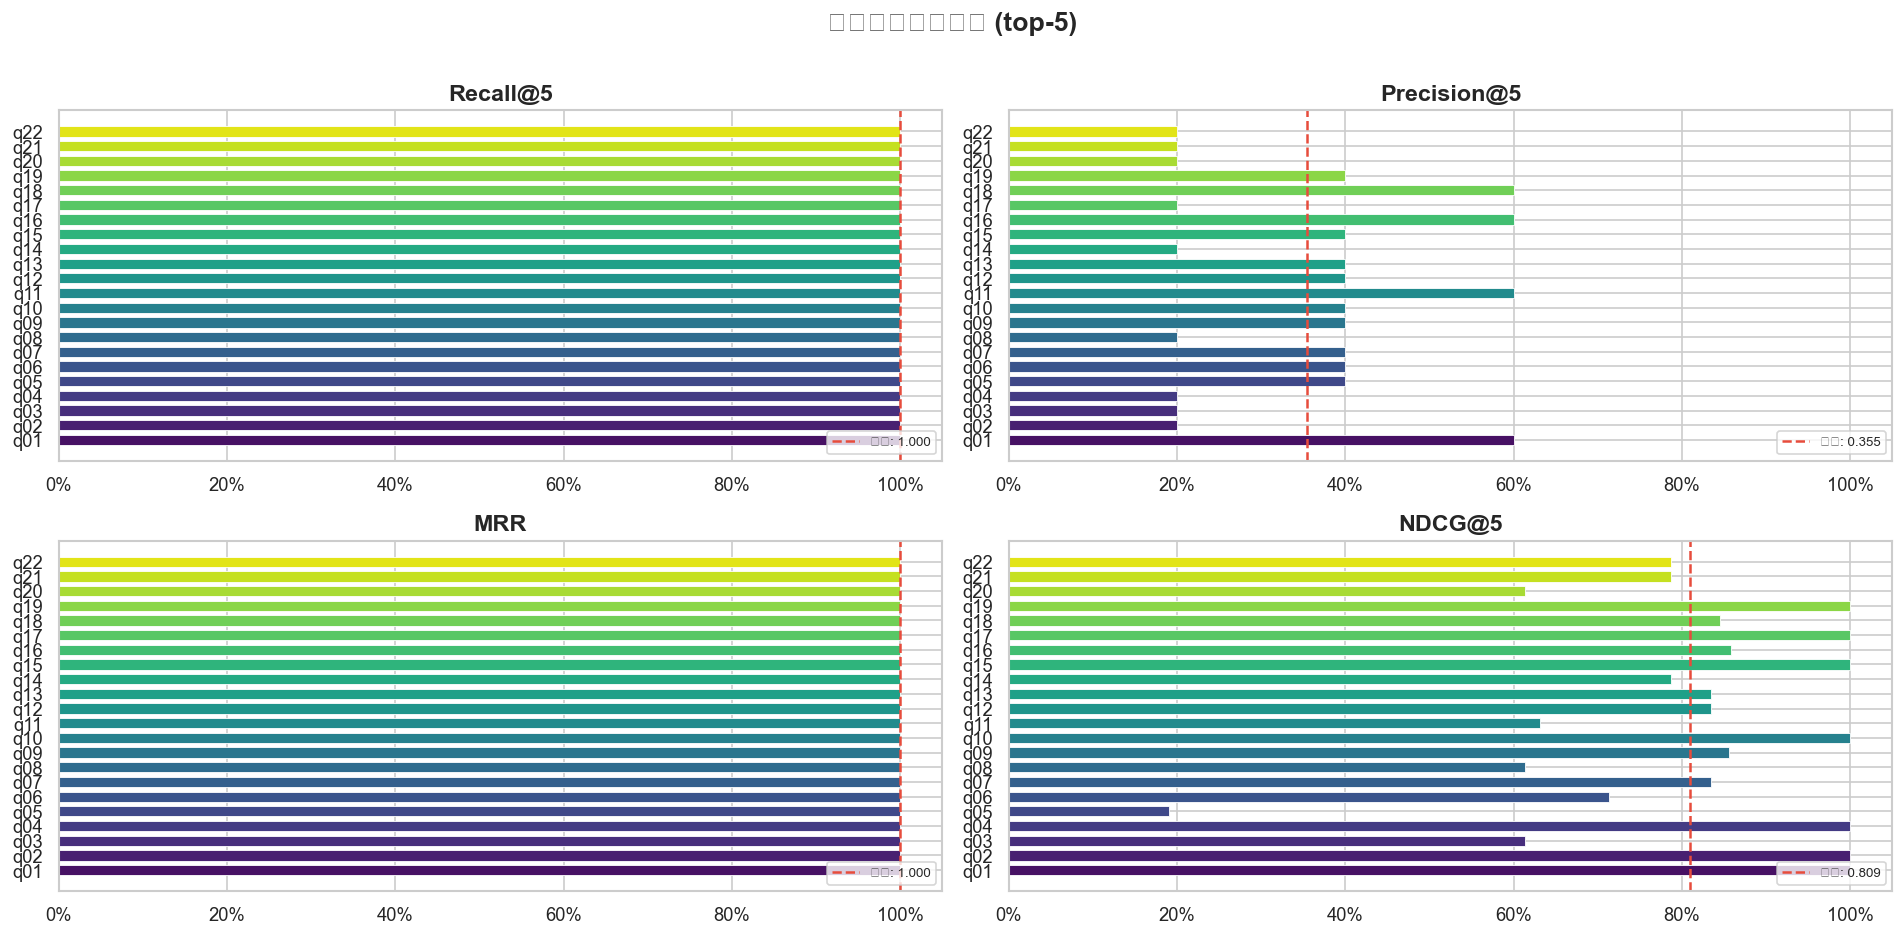

In [7]:
core_cols = [f"recall@{TOP_K}", f"precision@{TOP_K}", "mrr", f"ndcg@{TOP_K}"]
core_labels = [f"Recall@{TOP_K}", f"Precision@{TOP_K}", "MRR", f"NDCG@{TOP_K}"]
n_questions = len(df)

fig, axes = plt.subplots(2, 2, figsize=(16, max(6, n_questions * 0.35)))
fig.suptitle(f"逐题核心检索指标 (top-{TOP_K})", fontsize=16, fontweight="bold", y=1.01)

colors = sns.color_palette("viridis", n_questions)

for ax, col, label in zip(axes.flat, core_cols, core_labels):
    bars = ax.barh(df.index, df[col], color=colors, edgecolor="white", linewidth=0.5, height=0.7)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"均值: {mean_val:.3f}")
    ax.set_title(label, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 8. 逐题上下文质量

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2071857654.py:16: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2071857654.py:16: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2071857654.py:16: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2071857654.py:16: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/2071857654.py:16: UserWarning: Glyph 20313 (\N{CJK UNIFIED IDEOGRAPH-4F59}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.p

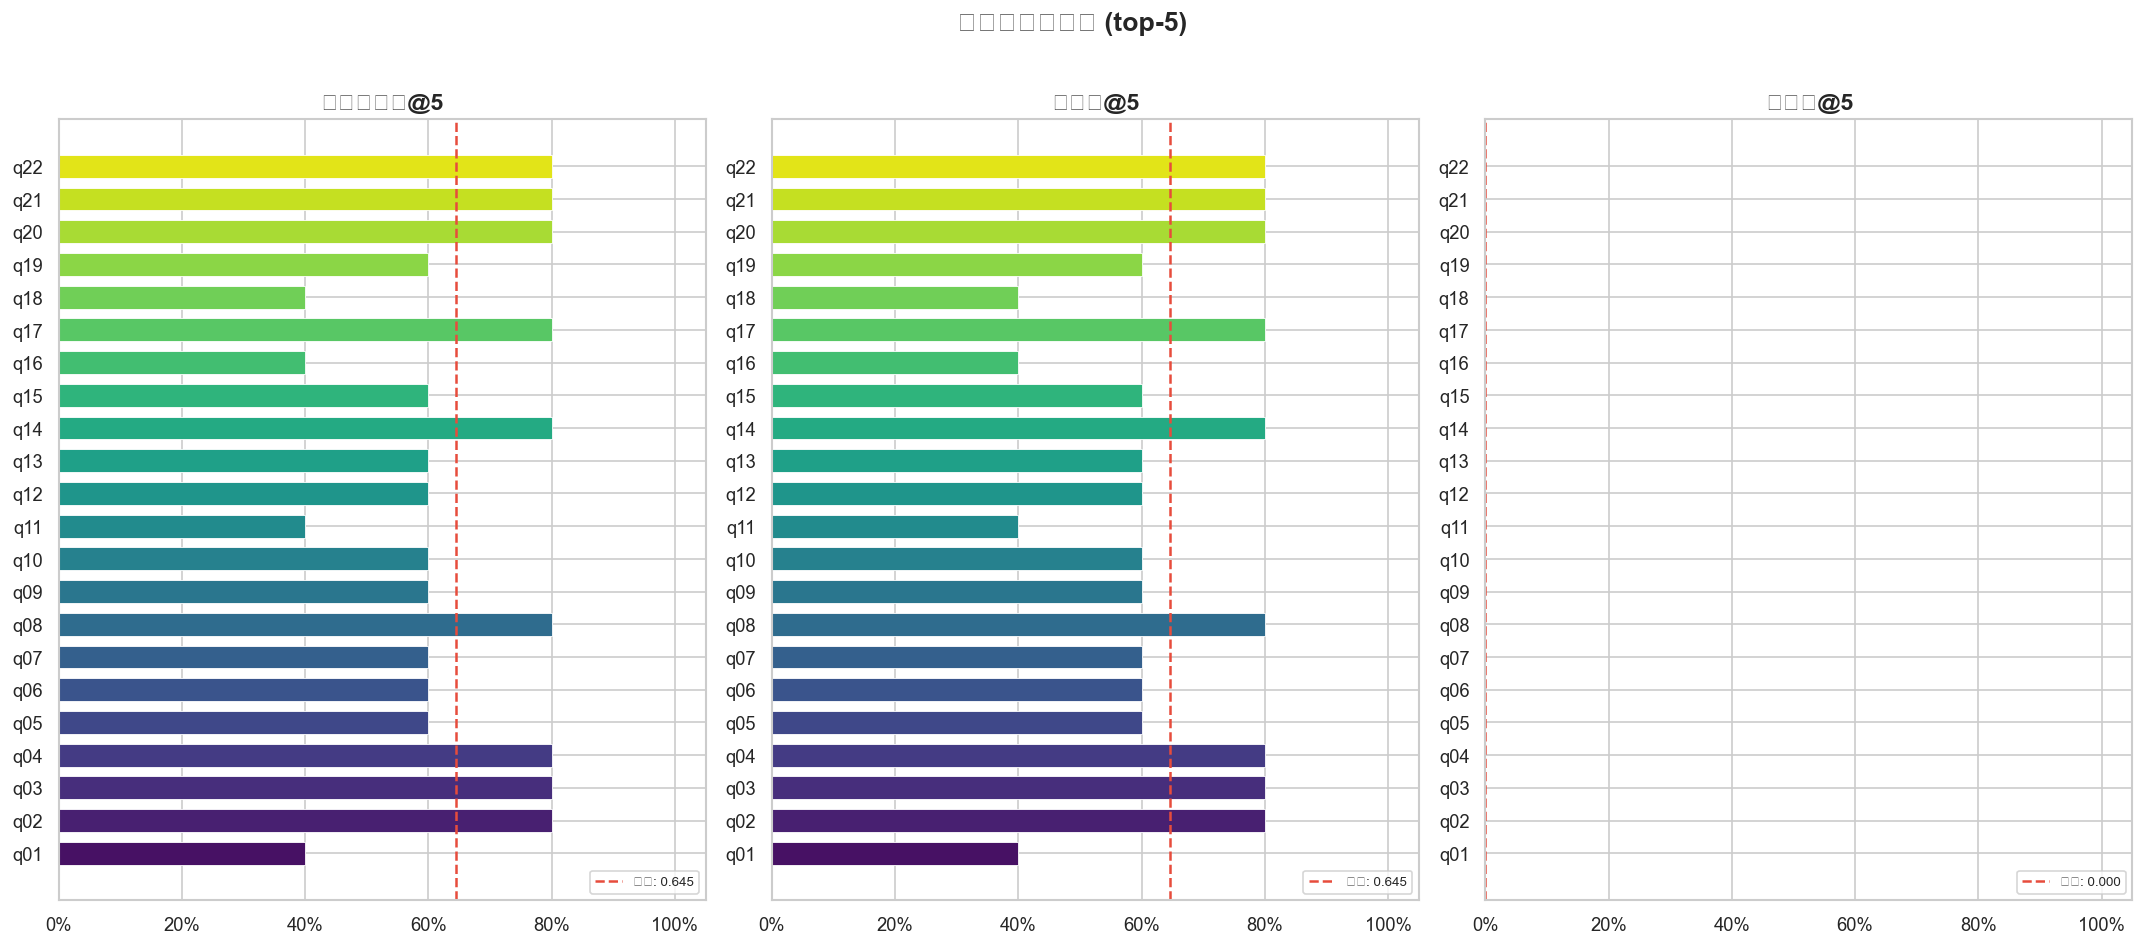

In [8]:
context_cols = [f"上下文冗余@{TOP_K}", f"无关率@{TOP_K}", f"重复率@{TOP_K}"]
context_labels = [f"上下文冗余@{TOP_K}", f"无关率@{TOP_K}", f"重复率@{TOP_K}"]

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, n_questions * 0.35)))
fig.suptitle(f"逐题上下文质量 (top-{TOP_K})", fontsize=16, fontweight="bold", y=1.02)

for ax, col, label in zip(axes, context_cols, context_labels):
    bars = ax.barh(df.index, df[col], color=colors, edgecolor="white", linewidth=0.5, height=0.7)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"均值: {mean_val:.3f}")
    ax.set_title(label, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 9. 聚合指标总览

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/670172474.py:38: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/670172474.py:38: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/670172474.py:38: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/670172474.py:38: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/670172474.py:38: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1

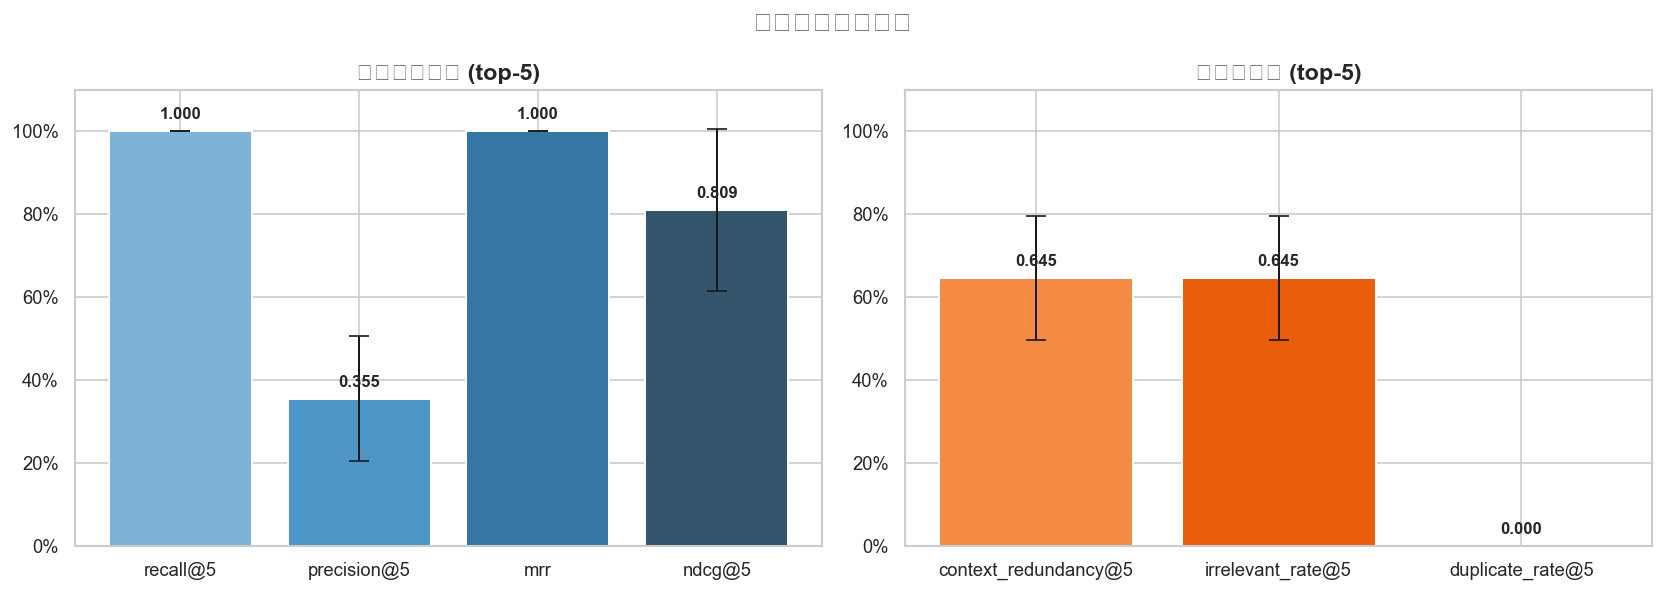

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("检索质量聚合总览", fontsize=16, fontweight="bold")

core_means = {k.replace("_mean", ""): v for k, v in agg["core_metrics"].items() if k.endswith("_mean")}
core_stds = {k.replace("_mean", ""): v for k, v in agg["core_metrics"].items() if k.endswith("_std")}

names = list(core_means.keys())
means = list(core_means.values())
stds = list(core_stds.values())
palette = sns.color_palette("Blues_d", len(names))

bars = axes[0].bar(names, means, yerr=stds, color=palette, edgecolor="white", linewidth=1.2,
                   capsize=6, error_kw={"linewidth": 1.2})
axes[0].set_title(f"核心检索指标 (top-{TOP_K})", fontweight="bold")
axes[0].set_ylim(0, 1.1)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

cq_means = {k.replace("_mean", ""): v for k, v in agg["context_quality"].items() if k.endswith("_mean")}
cq_stds = {k.replace("_mean", ""): v for k, v in agg["context_quality"].items() if k.endswith("_std")}

names_cq = list(cq_means.keys())
means_cq = list(cq_means.values())
stds_cq = list(cq_stds.values())
palette_cq = sns.color_palette("Oranges_d", len(names_cq))

bars_cq = axes[1].bar(names_cq, means_cq, yerr=stds_cq, color=palette_cq, edgecolor="white",
                      linewidth=1.2, capsize=6, error_kw={"linewidth": 1.2})
axes[1].set_title(f"上下文质量 (top-{TOP_K})", fontweight="bold")
axes[1].set_ylim(0, 1.1)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
for bar, val in zip(bars_cq, means_cq):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 10. 雷达图 — 检索质量画像

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3477119479.py:42: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3477119479.py:42: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3477119479.py:42: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3477119479.py:42: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3477119479.py:42: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

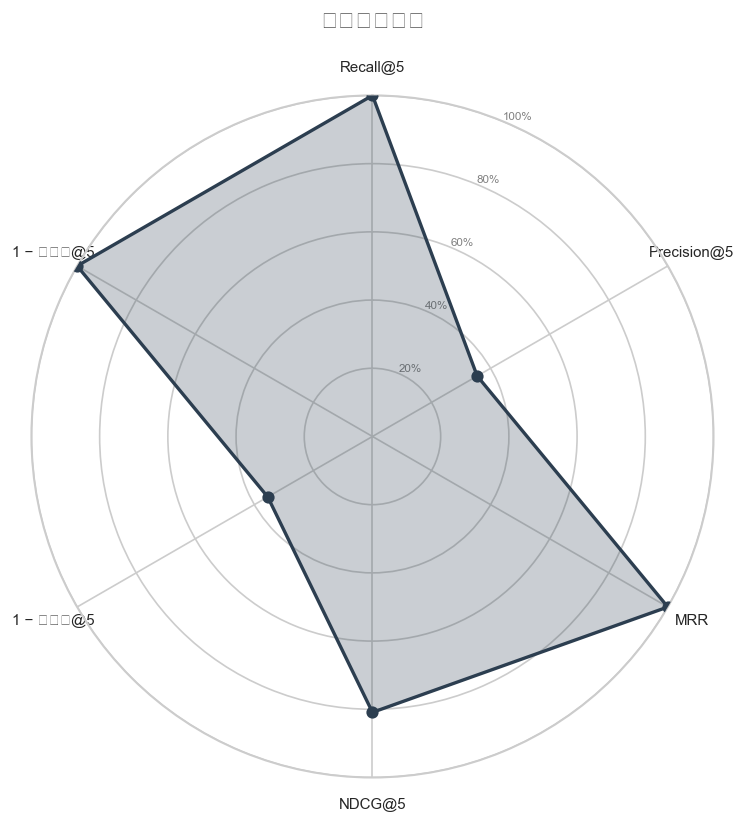

In [10]:
def plot_radar(ax, labels: list[str], values: list[float], title: str, color: str,
               linewidth: int = 2, alpha: float = 0.25) -> None:
    """在指定坐标轴绘制单张雷达图。"""
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    values += values[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=7, color="grey")
    ax.fill(angles, values, color=color, alpha=alpha)
    ax.plot(angles, values, color=color, linewidth=linewidth)
    for a, v in zip(angles[:-1], values[:-1]):
        ax.scatter(a, v, color=color, s=40, zorder=5)
    ax.set_title(title, fontweight="bold", pad=20)


radar_labels = [
    f"Recall@{TOP_K}",
    f"Precision@{TOP_K}",
    "MRR",
    f"NDCG@{TOP_K}",
    f"1 − 无关率@{TOP_K}",
    f"1 − 重复率@{TOP_K}",
]
radar_values = [
    df[f"recall@{TOP_K}"].mean(),
    df[f"precision@{TOP_K}"].mean(),
    df["mrr"].mean(),
    df[f"ndcg@{TOP_K}"].mean(),
    1.0 - df[f"无关率@{TOP_K}"].mean(),
    1.0 - df[f"重复率@{TOP_K}"].mean(),
]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
plot_radar(ax, radar_labels, radar_values, "检索质量画像", "#2c3e50")
plt.tight_layout()
plt.show()

## 11. Top-K 敏感度分析

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3121582266.py:60: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3121582266.py:60: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3121582266.py:60: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3121582266.py:60: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3121582266.py:60: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.p

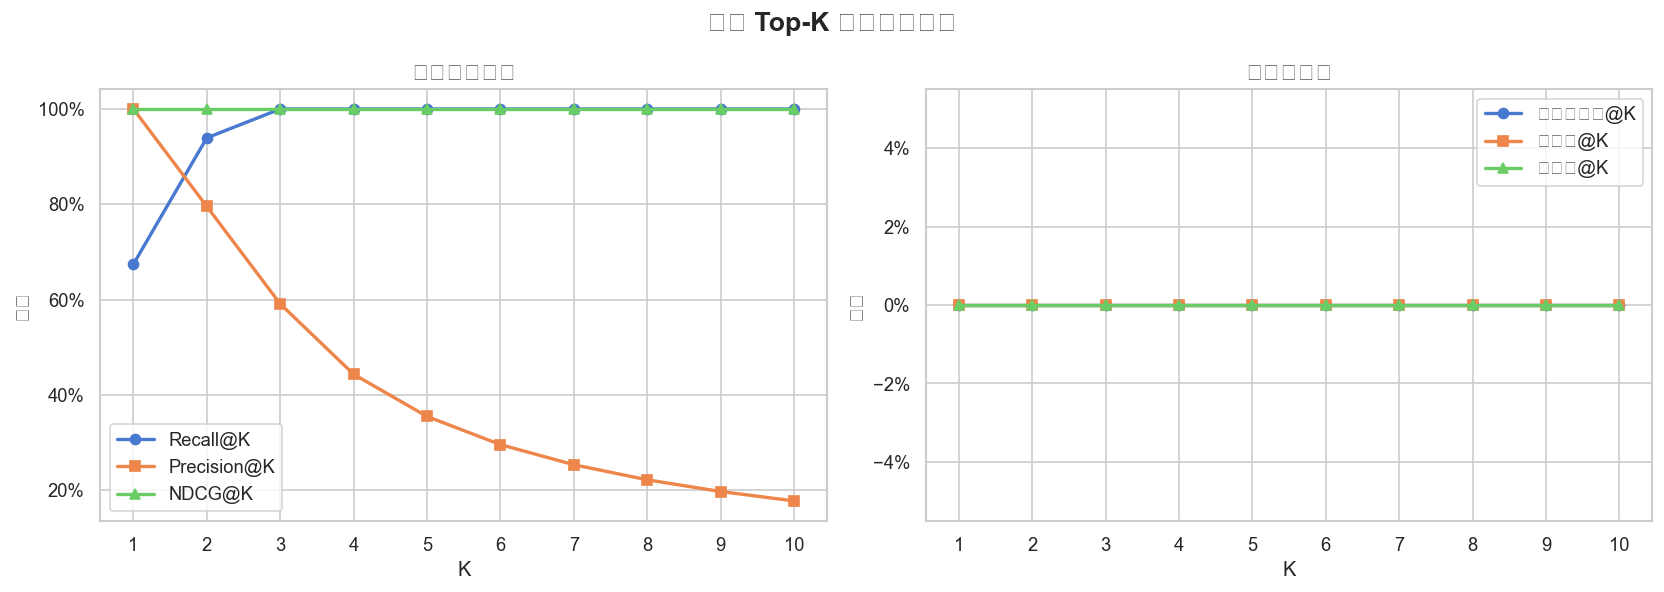

In [11]:
def compute_metrics_at_k(k: int) -> dict[str, float]:
    """用已有的检索结果重新计算不同 K 值下的聚合指标。"""
    vals: dict[str, list[float]] = {
        f"recall@{k}": [], f"precision@{k}": [], f"ndcg@{k}": [],
        f"context_redundancy@{k}": [], f"irrelevant_rate@{k}": [], f"duplicate_rate@{k}": [],
    }
    for r in per_question_results:
        ev = r["evaluation"]
        retrieved_ids = ev["retrieved_ids"]
        relevant_ids = set(ev["matched_relevant_ids"])
        relevance_scores_flat = {rid: 1.0 for rid in relevant_ids}

        vals[f"recall@{k}"].append(recall_at_k(retrieved_ids, relevant_ids, k))
        vals[f"precision@{k}"].append(precision_at_k(retrieved_ids, relevant_ids, k))
        vals[f"ndcg@{k}"].append(ndcg_at_k(retrieved_ids, k=k, relevance_scores=relevance_scores_flat))
        cq = context_redundancy_at_k(retrieved_ids, relevant_ids, k)
        vals[f"context_redundancy@{k}"].append(cq[f"context_redundancy@{k}"])
        vals[f"irrelevant_rate@{k}"].append(cq[f"irrelevant_rate@{k}"])
        vals[f"duplicate_rate@{k}"].append(cq[f"duplicate_rate@{k}"])

    return {name: mean(vlist) for name, vlist in vals.items()}


k_values = list(range(1, 11))
sensitivity: dict[str, list[float]] = {
    k: [] for k in ["recall", "precision", "ndcg", "redundancy", "irrelevant", "duplicate"]
}

for k in k_values:
    m = compute_metrics_at_k(k)
    for key in sensitivity:
        sensitivity[key].append(m.get(f"{key}@{k}" if key == "redundancy" else (
            f"context_{key}@{k}" if key in ("irrelevant", "duplicate") else f"{key}@{k}"), 0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("不同 Top-K 下的指标变化", fontsize=16, fontweight="bold")

ax = axes[0]
ax.plot(k_values, sensitivity["recall"], "o-", label="Recall@K", linewidth=2, markersize=6)
ax.plot(k_values, sensitivity["precision"], "s-", label="Precision@K", linewidth=2, markersize=6)
ax.plot(k_values, sensitivity["ndcg"], "^-", label="NDCG@K", linewidth=2, markersize=6)
ax.set_xlabel("K")
ax.set_ylabel("得分")
ax.set_title("核心检索指标", fontweight="bold")
ax.legend()
ax.set_xticks(k_values)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

ax = axes[1]
ax.plot(k_values, sensitivity["redundancy"], "o-", label="上下文冗余@K", linewidth=2, markersize=6)
ax.plot(k_values, sensitivity["irrelevant"], "s-", label="无关率@K", linewidth=2, markersize=6)
ax.plot(k_values, sensitivity["duplicate"], "^-", label="重复率@K", linewidth=2, markersize=6)
ax.set_xlabel("K")
ax.set_ylabel("比率")
ax.set_title("上下文质量", fontweight="bold")
ax.legend()
ax.set_xticks(k_values)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.show()

## 12. Recall 分布与精度关系

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 38382 (\N{CJK UNIFIED IDEOGRAPH-95EE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3208094415.py:42: UserWarning: Glyph 20313 (\N{CJK UNIFIED IDEOGRAPH-4F59}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chris/miniconda3/envs/localrag/lib/python3.11/si

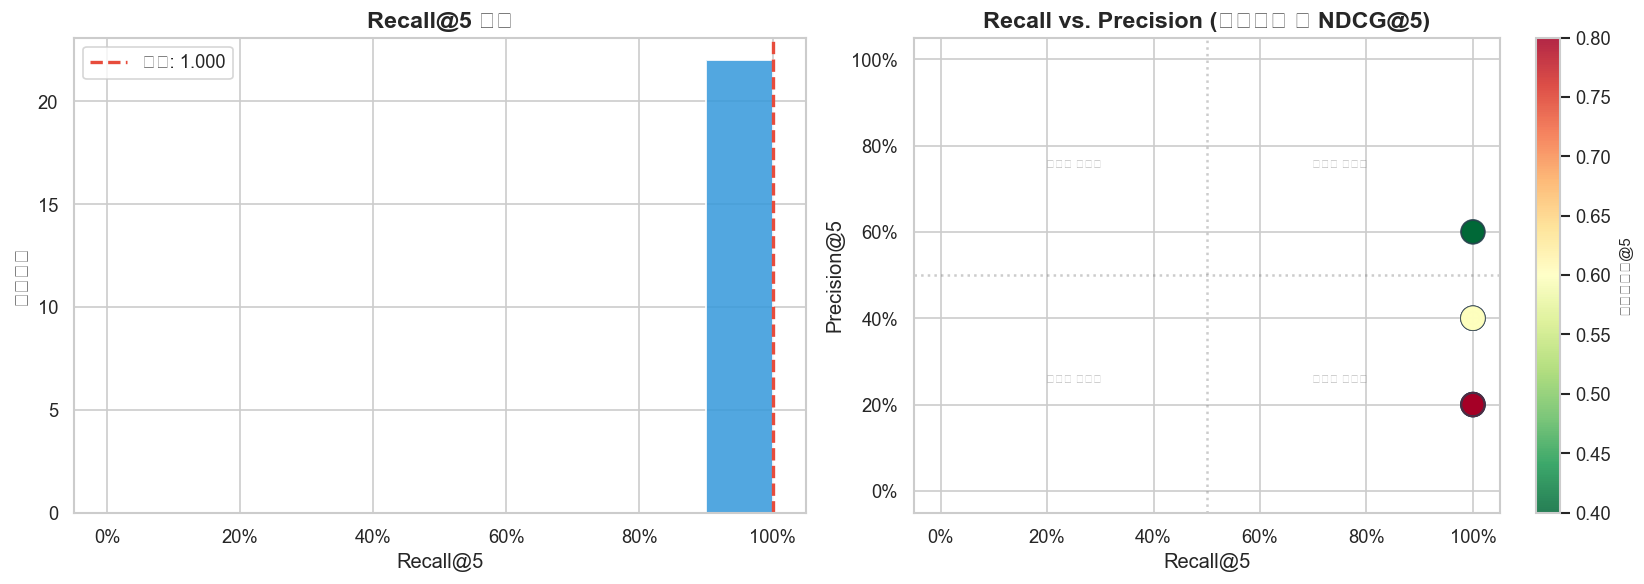

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins_recall = np.linspace(0, 1, 11)
ax.hist(df[f"recall@{TOP_K}"], bins=bins_recall, color="#3498db", edgecolor="white", linewidth=1.2, alpha=0.85)
ax.axvline(df[f"recall@{TOP_K}"].mean(), color="#e74c3c", linestyle="--", linewidth=2,
           label=f"均值: {df[f'recall@{TOP_K}'].mean():.3f}")
ax.set_title(f"Recall@{TOP_K} 分布", fontweight="bold")
ax.set_xlabel(f"Recall@{TOP_K}")
ax.set_ylabel("问题数量")
ax.legend()
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

ax = axes[1]
scatter = ax.scatter(
    df[f"recall@{TOP_K}"],
    df[f"precision@{TOP_K}"],
    s=df[f"ndcg@{TOP_K}"] * 200 + 20,
    c=df[f"上下文冗余@{TOP_K}"],
    cmap="RdYlGn_r",
    edgecolors="#2c3e50",
    linewidth=0.5,
    alpha=0.85,
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(f"上下文冗余@{TOP_K}", fontsize=9)
ax.set_xlabel(f"Recall@{TOP_K}")
ax.set_ylabel(f"Precision@{TOP_K}")
ax.set_title(f"Recall vs. Precision (气泡大小 ∝ NDCG@{TOP_K})", fontweight="bold")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.4)
ax.axvline(0.5, color="grey", linestyle=":", alpha=0.4)

ax.text(0.25, 0.25, "低召回 低精度", ha="center", fontsize=7, color="grey", alpha=0.7)
ax.text(0.75, 0.25, "高召回 低精度", ha="center", fontsize=7, color="grey", alpha=0.7)
ax.text(0.75, 0.75, "高召回 高精度", ha="center", fontsize=7, color="grey", alpha=0.7)
ax.text(0.25, 0.75, "低召回 高精度", ha="center", fontsize=7, color="grey", alpha=0.7)

plt.tight_layout()
plt.show()

## 13. 指标相关性热力图

/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20313 (\N{CJK UNIFIED IDEOGRAPH-4F59}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/chris/miniconda3/envs/l

/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20887 (\N{CJK UNIFIED IDEOGRAPH-5197}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.p

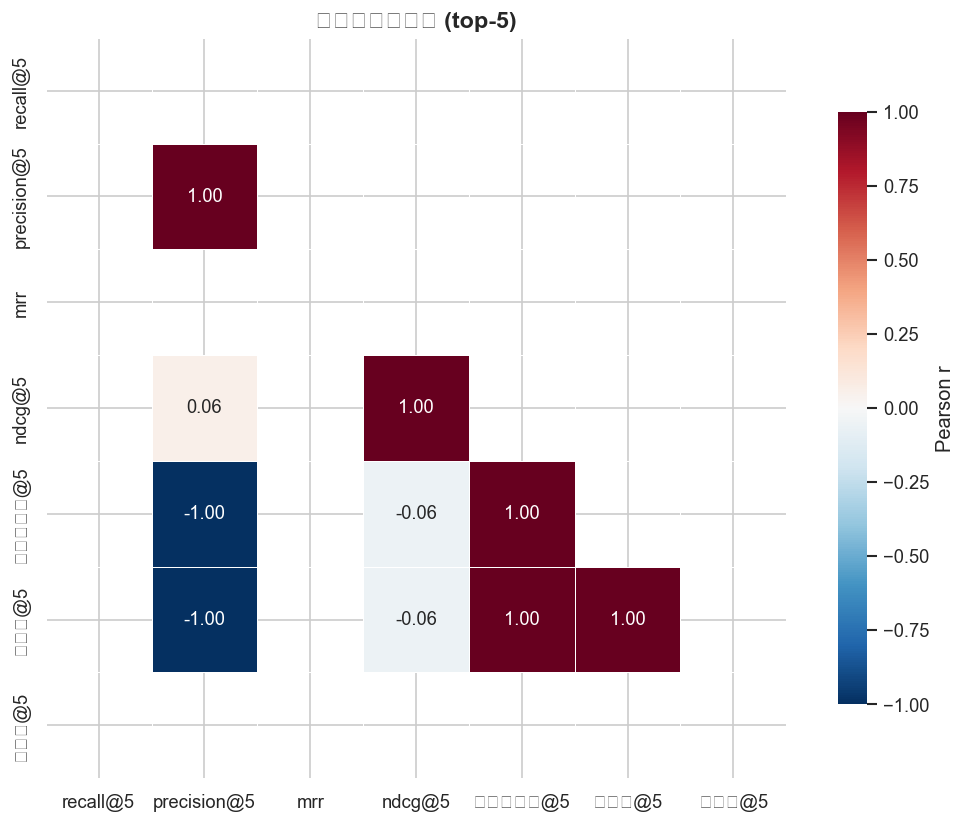

In [13]:
metric_cols = [
    f"recall@{TOP_K}", f"precision@{TOP_K}", "mrr", f"ndcg@{TOP_K}",
    f"上下文冗余@{TOP_K}", f"无关率@{TOP_K}", f"重复率@{TOP_K}",
]
corr = df[metric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title(f"指标相关性矩阵 (top-{TOP_K})", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

## 14. 导出报告

In [14]:
from datetime import datetime

report = {
    "report_schema": "retrieval-eval-v1",
    "experiment_name": EXPERIMENT_NAME,
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "evaluation_layer": "retrieval",
    "dataset": DATASET_PATH,
    "top_k": TOP_K,
    "mode": "live" if LIVE_MODE else "demo",
    "num_questions": len(per_question_results),
    "aggregate": {
        "core_metrics": {k: round(v, 4) for k, v in agg["core_metrics"].items()},
        "context_quality": {k: round(v, 4) for k, v in agg["context_quality"].items()},
    },
    "per_question": [
        {
            "id": r["id"],
            "question": r["question"],
            "core_metrics": r["evaluation"]["core_metrics"],
            "context_quality": r["evaluation"]["context_quality"],
        }
        for r in per_question_results
    ],
}

safe_name = "".join(c if c.isalnum() or c in "-_" else "_" for c in EXPERIMENT_NAME)
output_path = OUTPUT_DIR / f"{safe_name}.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)
    f.write("\n")

print(f"报告已导出: {output_path.resolve()}")
print(f"文件大小: {output_path.stat().st_size:,} bytes")

报告已导出: /Users/chris/Desktop/local-rag-system/evaluation/results/notebook-run.json
文件大小: 9,647 bytes


## 15. 自动诊断

In [15]:
recall_mean = df[f"recall@{TOP_K}"].mean()
precision_mean = df[f"precision@{TOP_K}"].mean()
mrr_mean = df["mrr"].mean()
redundancy_mean = df[f"上下文冗余@{TOP_K}"].mean()
ndcg_mean = df[f"ndcg@{TOP_K}"].mean()

diagnoses = []

if recall_mean > 0.7 and precision_mean < 0.4:
    diagnoses.append("高召回低精度 → 系统能找到相关文档，但上下文窗口噪声较多。建议增大 top-K 或引入 reranker。")
elif precision_mean > 0.7 and recall_mean < 0.4:
    diagnoses.append("高精度低召回 → 上下文干净但漏召回风险大。建议调整 chunk_size 或引入混合检索。")

if mrr_mean < 0.5:
    diagnoses.append("MRR 偏低 → 第一个相关文档排得太靠后，LLM 可能忽略关键证据。建议优化 embedding 模型或加入 reranker。")

if redundancy_mean > 0.4:
    diagnoses.append("上下文冗余偏高 → top-K 中无关或重复内容过多，浪费上下文窗口。检查 chunk_overlap 和去重策略。")

if ndcg_mean > 0.7:
    diagnoses.append("NDCG 表现优秀 → 高价值证据排名靠前，排序质量良好。")

if not diagnoses:
    diagnoses.append("指标表现均衡。随着知识库增长，继续监控即可。")

print("=" * 60)
print("诊断结果")
print("=" * 60)
for i, d in enumerate(diagnoses, 1):
    print(f"\n  {i}. {d}")
print()

诊断结果

  1. 高召回低精度 → 系统能找到相关文档，但上下文窗口噪声较多。建议增大 top-K 或引入 reranker。

  2. 上下文冗余偏高 → top-K 中无关或重复内容过多，浪费上下文窗口。检查 chunk_overlap 和去重策略。

  3. NDCG 表现优秀 → 高价值证据排名靠前，排序质量良好。



---
## 16. 分块策略对比 (Chunking Strategy Comparison)

以下单元格用于对比不同分块配置下的评估结果。

**使用流程：**
1. 修改 `.env` 中的 `CHUNK_SIZE` 和 `CHUNK_OVERLAP`
2. 重新摄入文档：`python ingest.py --input_dir data/engineering --batch_size 64`
3. 运行评估 CLI：`python evaluation/run_retrieval_eval.py --dataset evaluation/datasets/golden_retrieval.example.jsonl --top-k 5 --experiment-name chunk-800-120`
4. 重复以上步骤，每次使用不同的 `--experiment-name`（如 `chunk-500-80`、`chunk-1000-150`、`markdown-splitter-800-120`）
5. 回到本 notebook，运行以下单元格即可自动加载所有报告并生成对比图表

In [16]:
def load_all_reports(results_dir: str = "results") -> dict[str, dict[str, Any]]:
    """扫描 results 目录，加载所有 retrieval-eval-v1 格式的 JSON 报告。

    返回 {experiment_name: report_dict} 映射。
    """
    reports_dir = Path(results_dir)
    if not reports_dir.exists():
        return {}

    reports: dict[str, dict[str, Any]] = {}
    for file_path in sorted(reports_dir.glob("*.json")):
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            if data.get("report_schema") == "retrieval-eval-v1":
                name = data.get("experiment_name", file_path.stem)
                reports[name] = data
        except (json.JSONDecodeError, KeyError):
            continue
    return reports


reports = load_all_reports()

if not reports:
    print("⚠️ 未在 evaluation/results/ 目录中找到实验报告。")
    print()
    print("请先运行 CLI 评估工具生成报告，例如：")
    print()
    print("  python evaluation/run_retrieval_eval.py \\")
    print("    --dataset evaluation/datasets/golden_retrieval.example.jsonl \\")
    print("    --top-k 5 \\")
    print("    --experiment-name chunk-800-120")
    print()
    print("变更分块配置后重新摄入并运行不同 --experiment-name 的报告，")
    print("然后回到这里刷新单元格即可看到对比。")
    
    # 生成模拟对比数据用于演示
    print("\n--- 为演示对比功能，生成模拟实验数据 ---")
    demo_experiments = {
        "chunk-400-60": {
            "recall@5": 0.62, "precision@5": 0.48, "mrr": 0.65,
            "ndcg@5": 0.58, "context_redundancy@5": 0.28,
            "irrelevant_rate@5": 0.24, "duplicate_rate@5": 0.04,
        },
        "chunk-800-120": {
            "recall@5": 0.78, "precision@5": 0.42, "mrr": 0.74,
            "ndcg@5": 0.71, "context_redundancy@5": 0.42,
            "irrelevant_rate@5": 0.36, "duplicate_rate@5": 0.06,
        },
        "chunk-1000-150": {
            "recall@5": 0.85, "precision@5": 0.33, "mrr": 0.70,
            "ndcg@5": 0.68, "context_redundancy@5": 0.55,
            "irrelevant_rate@5": 0.48, "duplicate_rate@5": 0.07,
        },
        "markdown-header-800-120": {
            "recall@5": 0.82, "precision@5": 0.51, "mrr": 0.80,
            "ndcg@5": 0.77, "context_redundancy@5": 0.30,
            "irrelevant_rate@5": 0.25, "duplicate_rate@5": 0.05,
        },
    }
    reports = {
        name: {
            "experiment_name": name,
            "aggregate": {
                "core_metrics": {f"{k}_mean": v for k, v in metrics.items() if not k.startswith("context_") and not k.startswith("irrelevant_") and not k.startswith("duplicate_")},
                "context_quality": {
                    f"{k}_mean": v for k, v in metrics.items()
                    if k.startswith("context_") or k.startswith("irrelevant_") or k.startswith("duplicate_")
                },
            },
        }
        for name, metrics in demo_experiments.items()
    }
else:
    print(f"已加载 {len(reports)} 份实验报告:")
    for name in reports:
        print(f"  • {name}")

已加载 1 份实验报告:
  • notebook-run


### 16a. 策略对比汇总表

In [17]:
def extract_aggregate_means(report: dict[str, Any]) -> dict[str, float]:
    """从报告中提取聚合均值 (去掉 _mean 后缀)。"""
    agg = report["aggregate"]
    core = {k.replace("_mean", ""): v for k, v in agg["core_metrics"].items() if k.endswith("_mean")}
    cq = {k.replace("_mean", ""): v for k, v in agg["context_quality"].items() if k.endswith("_mean")}
    return {**core, **cq}


comparison_rows = []
for name, report in reports.items():
    metrics = extract_aggregate_means(report)
    metrics["实验名称"] = name
    comparison_rows.append(metrics)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.set_index("实验名称", inplace=True)

# 按 NDCG 降序排列
ndcg_col = [c for c in comparison_df.columns if c.startswith("ndcg@")][0]
comparison_df.sort_values(ndcg_col, ascending=False, inplace=True)

# 格式化显示
styled = comparison_df.style \
    .format("{:.4f}") \
    .background_gradient(cmap="RdYlGn", subset=[c for c in comparison_df.columns if not c.startswith("irrelevant") and not c.startswith("duplicate") and not c.startswith("context_redundancy")]) \
    .background_gradient(cmap="RdYlGn_r", subset=[c for c in comparison_df.columns if c.startswith("irrelevant") or c.startswith("duplicate") or c.startswith("context_redundancy")]) \
    .set_caption("分块策略检索指标对比 (绿色=优, 红色=差)")
styled

,recall@5,precision@5,mrr,ndcg@5,context_redundancy@5,irrelevant_rate@5,duplicate_rate@5
实验名称,,,,,,,
notebook-run,1.0000,0.3545,1.0000,0.8089,0.6455,0.6455,0.0000


### 16b. 核心指标对比柱状图

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1439746456.py:27: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1439746456.py:27: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1439746456.py:27: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1439746456.py:27: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1439746456.py:27: UserWarning: Glyph 22359 (\N{CJK UNIFIED IDEOGRAPH-5757}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chris/miniconda3/envs/localrag/lib/python3.11/site-packages/IPython/core/pylabtools.p

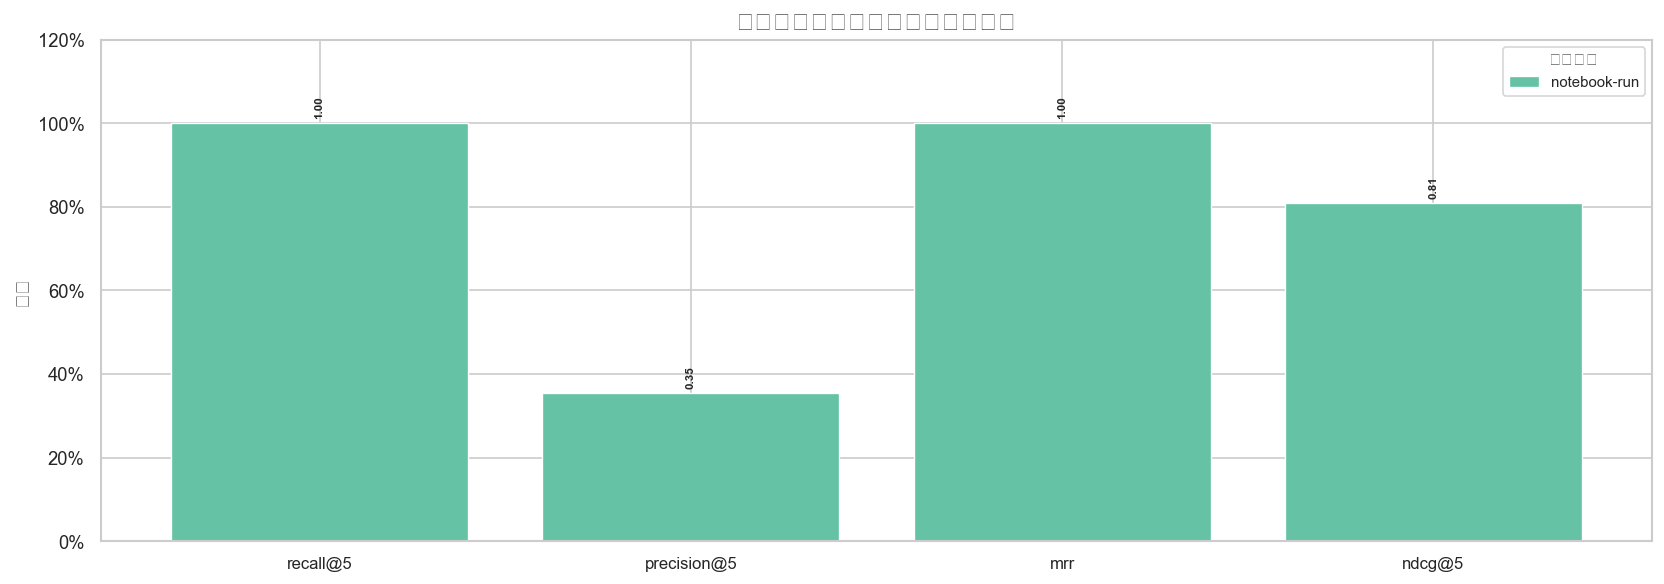

In [18]:
core_metric_names = [c for c in comparison_df.columns if not c.startswith("context_") and not c.startswith("irrelevant_") and not c.startswith("duplicate_")]
n_strategies = len(comparison_df)
n_metrics = len(core_metric_names)

fig, ax = plt.subplots(figsize=(14, max(5, n_strategies * 1.2)))

x = np.arange(n_metrics)
bar_width = 0.8 / n_strategies
colors = sns.color_palette("Set2", n_strategies)

for i, (name, row) in enumerate(comparison_df.iterrows()):
    vals = [row[c] for c in core_metric_names]
    offset = (i - n_strategies / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals, bar_width, label=name, color=colors[i], edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f"{val:.2f}", ha="center", fontsize=7, fontweight="bold", rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(core_metric_names, fontsize=10)
ax.set_ylim(0, 1.2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("不同分块策略的核心检索指标对比", fontweight="bold", fontsize=15)
ax.legend(loc="upper right", fontsize=9, title="分块策略", title_fontsize=10)
ax.set_ylabel("得分")

plt.tight_layout()
plt.show()

### 16c. 上下文质量对比

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/4275499710.py:24: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/4275499710.py:24: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/4275499710.py:24: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/4275499710.py:24: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/4275499710.py:24: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

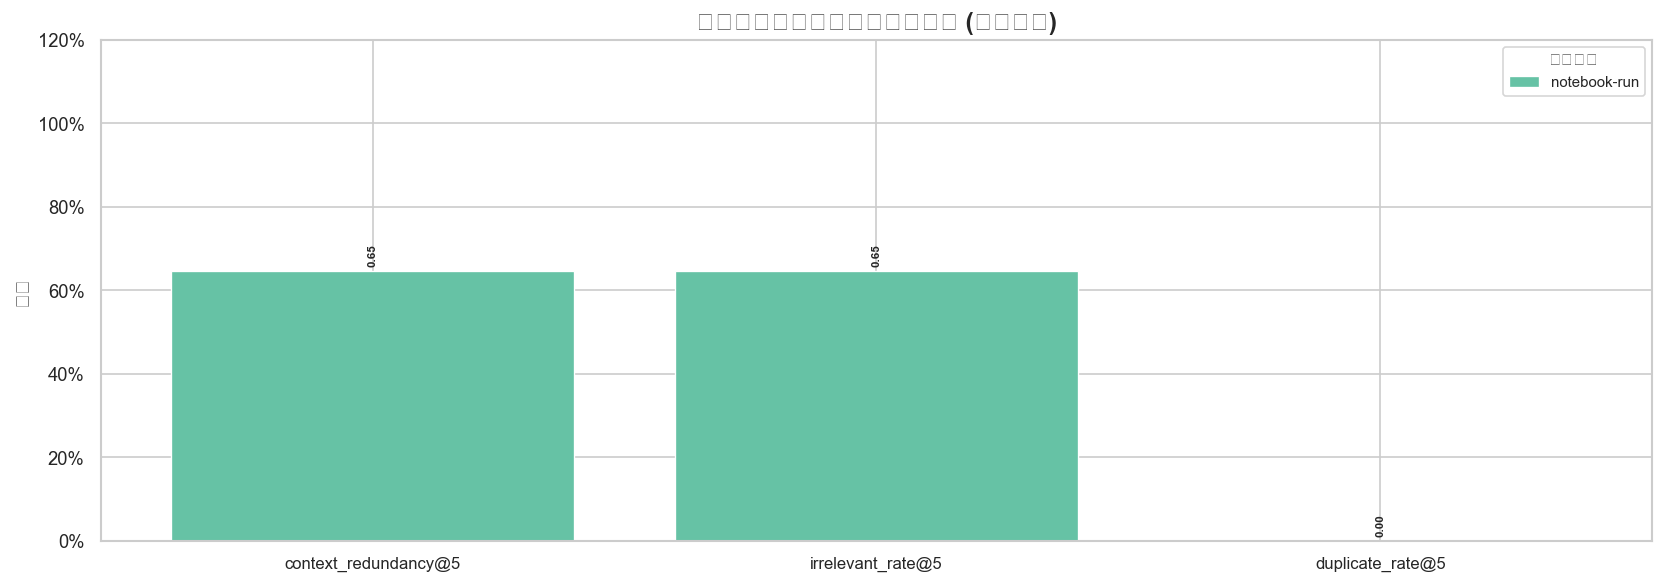

In [19]:
cq_metric_names = [c for c in comparison_df.columns if c.startswith("context_") or c.startswith("irrelevant_") or c.startswith("duplicate_")]

fig, ax = plt.subplots(figsize=(14, max(5, n_strategies * 1.2)))

x = np.arange(len(cq_metric_names))
bar_width = 0.8 / n_strategies

for i, (name, row) in enumerate(comparison_df.iterrows()):
    vals = [row[c] for c in cq_metric_names]
    offset = (i - n_strategies / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, vals, bar_width, label=name, color=colors[i], edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f"{val:.2f}", ha="center", fontsize=7, fontweight="bold", rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(cq_metric_names, fontsize=10)
ax.set_ylim(0, 1.2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("不同分块策略的上下文质量对比 (越低越好)", fontweight="bold", fontsize=15)
ax.legend(loc="upper right", fontsize=9, title="分块策略", title_fontsize=10)
ax.set_ylabel("比率")

plt.tight_layout()
plt.show()

### 16d. 雷达图叠加对比

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1220048378.py:49: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1220048378.py:49: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1220048378.py:49: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1220048378.py:49: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/1220048378.py:49: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

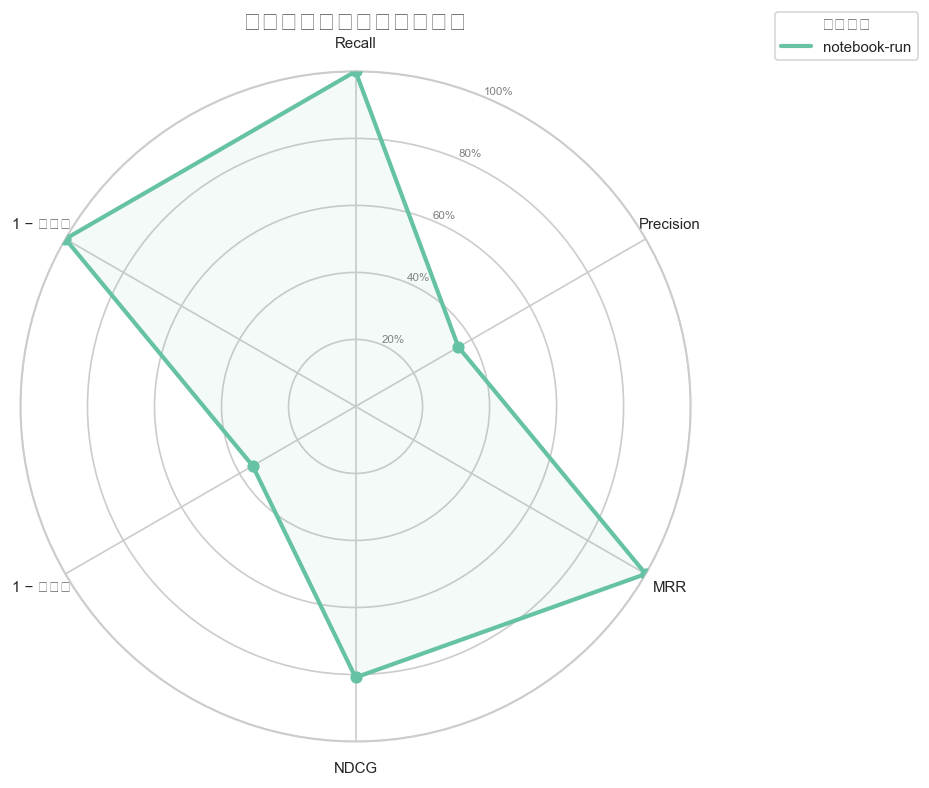

In [20]:
radar_metric_keys = [
    ("recall@", "Recall"),
    ("precision@", "Precision"),
    ("mrr", "MRR"),
    ("ndcg@", "NDCG"),
]

def _find_key(prefix: str, keys: list[str]) -> str:
    for k in keys:
        if k.startswith(prefix):
            return k
    return prefix

cq_invert_keys = [
    ("irrelevant_rate@", "1 − 无关率"),
    ("duplicate_rate@", "1 − 重复率"),
]

radar_labels_cmp = []
for _, label in radar_metric_keys:
    radar_labels_cmp.append(label)
for _, label in cq_invert_keys:
    radar_labels_cmp.append(label)

all_keys = list(comparison_df.columns)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
colors_cmp = sns.color_palette("Set2", n_strategies)

for i, (name, row) in enumerate(comparison_df.iterrows()):
    values = []
    for prefix, _ in radar_metric_keys:
        k = _find_key(prefix, all_keys)
        values.append(row.get(k, 0))
    for prefix, _ in cq_invert_keys:
        k = _find_key(prefix, all_keys)
        values.append(1.0 - row.get(k, 0))
    plot_radar(ax, radar_labels_cmp, values, "", colors_cmp[i],
               linewidth=2.5, alpha=0.08)

ax.set_title("分块策略检索质量画像叠加", fontweight="bold", pad=25, fontsize=15)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors_cmp[i], linewidth=2.5, label=name)
                   for i, name in enumerate(comparison_df.index)]
ax.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.35, 1.1),
          fontsize=9, title="分块策略", title_fontsize=10)

plt.tight_layout()
plt.show()

### 16e. 权衡分析 — Recall vs. Precision vs. 冗余率

/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3719482696.py:39: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3719482696.py:39: UserWarning: Glyph 22359 (\N{CJK UNIFIED IDEOGRAPH-5757}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3719482696.py:39: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3719482696.py:39: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipykernel_1749/3719482696.py:39: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/_x/sfkhblrx79d_4wls4pyd9p1m0000gn/T/ipyker

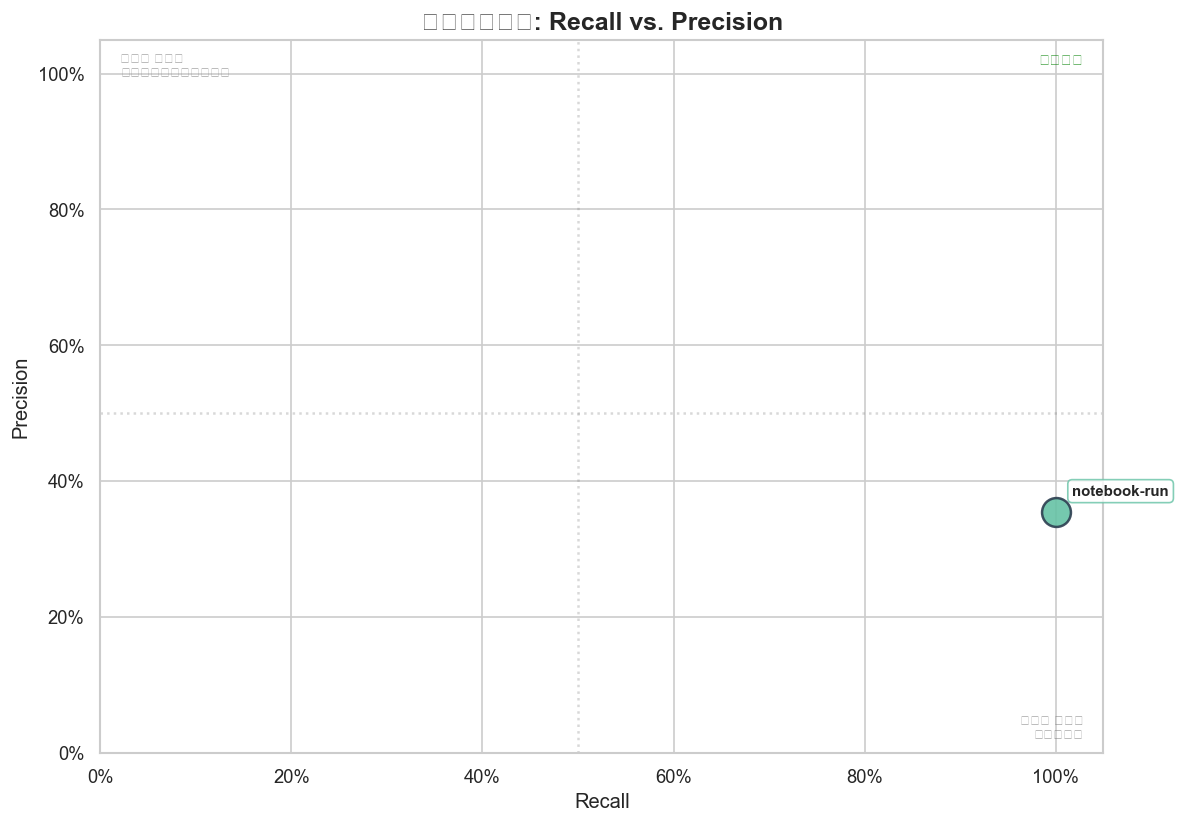

In [21]:
recall_key = _find_key("recall@", all_keys)
precision_key = _find_key("precision@", all_keys)
redundancy_key = _find_key("context_redundancy@", all_keys)
ndcg_key = _find_key("ndcg@", all_keys)

fig, ax = plt.subplots(figsize=(10, 7))

for i, (name, row) in enumerate(comparison_df.iterrows()):
    ax.scatter(
        row[recall_key], row[precision_key],
        s=300, color=colors_cmp[i], edgecolors="#2c3e50",
        linewidth=1.5, alpha=0.9, zorder=5,
    )
    ax.annotate(
        name,
        (row[recall_key], row[precision_key]),
        textcoords="offset points", xytext=(10, 10),
        fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor=colors_cmp[i]),
    )

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("分块策略权衡: Recall vs. Precision", fontweight="bold", fontsize=15)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.3)
ax.axvline(0.5, color="grey", linestyle=":", alpha=0.3)

ax.text(0.02, 0.98, "高精度 低召回\n上下文干净但可能漏召回",
        transform=ax.transAxes, fontsize=8, color="grey", va="top")
ax.text(0.98, 0.02, "高召回 低精度\n全但噪声多",
        transform=ax.transAxes, fontsize=8, color="grey", ha="right")
ax.text(0.98, 0.98, "理想区域",
        transform=ax.transAxes, fontsize=9, color="green", ha="right", va="top", fontweight="bold")

plt.tight_layout()
plt.show()

### 16f. 逐题召回差异热力图

展示每个问题在不同策略下的 Recall 差异，快速定位哪些问题对分块策略敏感。

In [22]:
# 仅当存在真实报告时才尝试构建逐题对比（模拟数据无 per_question 字段）
has_per_question = all(
    "per_question" in report and len(report.get("per_question", [])) > 0
    for report in reports.values()
)

if has_per_question and len(reports) >= 2:
    question_ids = [q["id"] for q in list(reports.values())[0]["per_question"]]

    heatmap_data = {}
    for name, report in reports.items():
        top_k = report.get("top_k", TOP_K)
        heatmap_data[name] = [
            q["core_metrics"].get(f"recall@{top_k}", 0)
            for q in report["per_question"]
        ]

    heatmap_df = pd.DataFrame(heatmap_data, index=question_ids)

    fig, ax = plt.subplots(figsize=(max(8, len(reports) * 2), max(6, len(question_ids) * 0.35)))
    sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=1, linecolor="white", ax=ax, cbar_kws={"label": "Recall"})
    ax.set_title("不同策略下逐题 Recall 对比", fontweight="bold", fontsize=15)
    ax.set_ylabel("问题 ID")
    ax.set_xlabel("分块策略")
    plt.tight_layout()
    plt.show()
else:
    print("需要至少 2 份包含逐题数据的真实报告才能生成此热力图。")
    print("请运行 CLI 评估工具生成真实报告后回来刷新。")

需要至少 2 份包含逐题数据的真实报告才能生成此热力图。
请运行 CLI 评估工具生成真实报告后回来刷新。
